In [1]:
import json
from pathlib import Path

import awkward as ak
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import vector
from enreg.tools import general as g

plt.style.use('default')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f"{x:.4f}")


In [2]:
def to_p4(p4_obj):
    return vector.awk(
        ak.zip(
            {
                "mass": p4_obj.tau,
                "x": p4_obj.x,
                "y": p4_obj.y,
                "z": p4_obj.z,
            }
        )
    )


def wrap_delta_phi(delta_phi):
    return np.arctan2(np.sin(delta_phi), np.cos(delta_phi))


def width68(values):
    q16, q84 = np.quantile(values, [0.16, 0.84])
    return 0.5 * (q84 - q16)


def median_abs_error(values):
    return np.median(np.abs(values))


def make_np_p4(pt, eta, phi, mass):
    return vector.array({
        'pt': np.asarray(pt),
        'eta': np.asarray(eta),
        'phi': np.asarray(phi),
        'mass': np.asarray(mass),
    })


def compute_binned_stats(x_values, bins, values, stat_fn, min_count=50):
    centers = 0.5 * (bins[:-1] + bins[1:])
    stats = []
    counts = []
    for low, high in zip(bins[:-1], bins[1:]):
        mask = (x_values >= low) & (x_values < high)
        count = int(np.sum(mask))
        counts.append(count)
        if count < min_count:
            stats.append(np.nan)
        else:
            stats.append(stat_fn(values[mask]))
    return centers, np.asarray(stats), np.asarray(counts)


def print_bin_counts(name, bins, counts):
    print(name)
    for low, high, count in zip(bins[:-1], bins[1:], counts):
        print(f'  [{low:.2f}, {high:.2f}): {count}')
    print()


def iqr(values):
    return np.quantile(values, 0.75) - np.quantile(values, 0.25)


def normalized_iqr(values):
    q25, q50, q75 = np.quantile(values, [0.25, 0.50, 0.75])
    return (q75 - q25) / q50 if q50 != 0 else np.nan


def residual_iqr(values):
    return iqr(values)


In [3]:
run_dir = Path('/home/norman/ml-tau/ml-tau-en-reg/training-outputs/260319_p4_regression_z_tautau_91_e150/jet_regression/ParticleTransformer__log_pt_delta_eta_delta_phi_log_mass')
history_path = run_dir / 'history.json'

test_sample_names = ['z_test.parquet']
source_base_dir = Path('/scratch/persistent/norman/ml-tau/cld/v1.2.3_key4hep_2025-05-29_CLD_f1e8f9/260319')
source_test_path = source_base_dir / 'z_test.parquet'
pt_bins = np.array([5, 10, 15, 20, 25, 30, 35, 40, 45, 50])
pt_centers = 0.5 * (pt_bins[:-1] + pt_bins[1:])

component_names = ['pt', 'eta', 'phi', 'mass']
component_labels = {
    'pt': r'$p_T$ [GeV]',
    'eta': r'$\eta$',
    'phi': r'$\phi$ [rad]',
    'mass': 'mass [GeV]',
}

with open(history_path, 'r') as f:
    history = json.load(f)


def get_gen_p4(data):
    if 'gen_jet_tau_p4s' in ak.fields(data):
        return to_p4(data['gen_jet_tau_p4s'])
    if 'gen_tau_p4s' in ak.fields(data):
        return to_p4(data['gen_tau_p4s'])
    raise KeyError('No gen tau four-vector field found in source parquet.')


def load_run_predictions(run_directory, sample_names):
    pred_blocks = []
    target_blocks = []
    loaded_samples = []
    for sample_name in sample_names:
        sample_path = run_directory / sample_name
        if not sample_path.exists():
            continue
        sample_data = ak.from_parquet(sample_path)
        pred_blocks.append(np.asarray(sample_data['jet_regression']['pred']))
        target_blocks.append(np.asarray(sample_data['jet_regression']['target']))
        loaded_samples.append(sample_name)
    if not pred_blocks:
        raise FileNotFoundError(f'No prediction parquet found in {run_directory} for {sample_names}')
    return np.concatenate(pred_blocks, axis=0), np.concatenate(target_blocks, axis=0), loaded_samples


def load_source_data(sample_names):
    source_blocks = []
    loaded_samples = []
    for sample_name in sample_names:
        sample_path = source_base_dir / sample_name
        if not sample_path.exists():
            continue
        source_blocks.append(ak.from_parquet(sample_path))
        loaded_samples.append(sample_name)
    if not source_blocks:
        return None, []
    return ak.concatenate(source_blocks, axis=0), loaded_samples


def build_run_eval(run_directory, sample_names):
    preds_local, targets_local, loaded_samples = load_run_predictions(run_directory, sample_names)
    pred_pt_local, pred_eta_local, pred_phi_local, pred_mass_local = preds_local.T
    true_pt_local, true_eta_local, true_phi_local, true_mass_local = targets_local.T
    pred_p4_local = make_np_p4(pred_pt_local, pred_eta_local, pred_phi_local, pred_mass_local)
    true_p4_local = make_np_p4(true_pt_local, true_eta_local, true_phi_local, true_mass_local)
    return {
        'run_dir': run_directory,
        'sample_names': loaded_samples,
        'preds': preds_local,
        'targets': targets_local,
        'pred_pt': pred_pt_local,
        'pred_eta': pred_eta_local,
        'pred_phi': pred_phi_local,
        'pred_mass': pred_mass_local,
        'true_pt': true_pt_local,
        'true_eta': true_eta_local,
        'true_phi': true_phi_local,
        'true_mass': true_mass_local,
        'pt_response': pred_pt_local / true_pt_local,
        'mass_response': pred_mass_local / true_mass_local,
        'eta_residual': pred_eta_local - true_eta_local,
        'phi_residual': wrap_delta_phi(pred_phi_local - true_phi_local),
        'pred_p4': pred_p4_local,
        'true_p4': true_p4_local,
        'delta_r_pred_gen': np.asarray(pred_p4_local.deltaR(true_p4_local)),
    }


run_eval = build_run_eval(run_dir, test_sample_names)
preds = run_eval['preds']
targets = run_eval['targets']
pred_pt = run_eval['pred_pt']
pred_eta = run_eval['pred_eta']
pred_phi = run_eval['pred_phi']
pred_mass = run_eval['pred_mass']
true_pt = run_eval['true_pt']
true_eta = run_eval['true_eta']
true_phi = run_eval['true_phi']
true_mass = run_eval['true_mass']
pt_response = run_eval['pt_response']
mass_response = run_eval['mass_response']
eta_residual = run_eval['eta_residual']
phi_residual = run_eval['phi_residual']
gen_p4 = run_eval['true_p4']
pred_p4 = run_eval['pred_p4']
delta_r_pred_gen = run_eval['delta_r_pred_gen']

source_data, loaded_source_samples = load_source_data(run_eval['sample_names'])
source_available = source_data is not None

if source_available:
    if len(source_data) != len(preds):
        raise ValueError(
            f'Source/test length mismatch for {run_eval["sample_names"]}: '
            f'{len(source_data)} source jets vs {len(preds)} predicted jets.'
        )
    reco_p4 = to_p4(source_data['reco_jet_p4s'])
    source_gen_p4 = get_gen_p4(source_data)
else:
    reco_p4 = None
    source_gen_p4 = None

summary_df = pd.DataFrame({
    'pred_pt': pred_pt,
    'true_pt': true_pt,
    'pt_response': pt_response,
    'pred_eta': pred_eta,
    'true_eta': true_eta,
    'eta_residual': eta_residual,
    'pred_phi': pred_phi,
    'true_phi': true_phi,
    'phi_residual': phi_residual,
    'pred_mass': pred_mass,
    'true_mass': true_mass,
    'mass_response': mass_response,
    'deltaR_pred_gen': delta_r_pred_gen,
})

print(f'Loaded run: {run_dir}')
print(f'Loaded prediction samples: {run_eval["sample_names"]}')
print(f'History epochs: {len(history["loss_train"])}')
print(f'Test jets: {len(preds)}')
print(f'Original source parquet available: {source_available}')
summary_df.head()


Loaded run: /home/norman/ml-tau/ml-tau-en-reg/training-outputs/260319_p4_regression_z_tautau_91_e150/jet_regression/ParticleTransformer__log_pt_delta_eta_delta_phi_log_mass
Loaded prediction samples: ['z_test.parquet']
History epochs: 150
Test jets: 25895
Original source parquet available: True


,pred_pt,true_pt,pt_response,pred_eta,true_eta,eta_residual,pred_phi,true_phi,phi_residual,pred_mass,true_mass,mass_response,deltaR_pred_gen
0,12.2753,12.4253,0.9879,1.7779,1.7459,0.0320,0.0793,0.0592,0.0201,0.8844,0.9756,0.9065,0.0378
1,35.2988,33.2104,1.0629,0.1340,0.1074,0.0267,-1.9626,-1.9806,0.0180,0.8535,0.9840,0.8673,0.0322
2,25.4251,25.3499,1.0030,1.1085,1.1009,0.0076,1.2185,1.2654,-0.0469,1.4586,1.4352,1.0163,0.0475
3,3.7731,3.8307,0.9850,-2.4495,-2.4134,-0.0361,-1.2807,-1.2846,0.0039,0.7924,0.8082,0.9805,0.0363
4,33.3737,33.2060,1.0050,-0.5040,-0.5171,0.0131,-1.9197,-1.9326,0.0129,0.1490,0.1396,1.0679,0.0184


In [4]:
# Target-space diagnostic: compare the trained model against the zero-correction baseline.
# Zero correction means keeping the reco jet unchanged in reconstructed space.
if source_available:
    reco_pt_target = np.asarray(reco_p4.pt)
    reco_eta_target = np.asarray(reco_p4.eta)
    reco_phi_target = np.asarray(reco_p4.phi)
    reco_mass_target = np.asarray(reco_p4.mass)

    target_eps = 1e-6
    pred_delta_phi_target = wrap_delta_phi(pred_phi - reco_phi_target)
    true_delta_phi_target = wrap_delta_phi(true_phi - reco_phi_target)

    pred_target_map = {
        'log_pt': np.log(np.clip(pred_pt, target_eps, None) / np.clip(reco_pt_target, target_eps, None)),
        'delta_phi': pred_delta_phi_target,
        'sin_delta_phi': np.sin(pred_delta_phi_target),
        'cos_delta_phi': np.cos(pred_delta_phi_target),
        'delta_eta': pred_eta - reco_eta_target,
        'log_mass': np.log((np.clip(pred_mass, 0.0, None) + target_eps) / (np.clip(reco_mass_target, 0.0, None) + target_eps)),
    }

    true_target_map = {
        'log_pt': np.log(np.clip(true_pt, target_eps, None) / np.clip(reco_pt_target, target_eps, None)),
        'delta_phi': true_delta_phi_target,
        'sin_delta_phi': np.sin(true_delta_phi_target),
        'cos_delta_phi': np.cos(true_delta_phi_target),
        'delta_eta': true_eta - reco_eta_target,
        'log_mass': np.log((np.clip(true_mass, 0.0, None) + target_eps) / (np.clip(reco_mass_target, 0.0, None) + target_eps)),
    }

    zero_target_map = {
        'log_pt': np.zeros_like(true_pt),
        'delta_phi': np.zeros_like(true_phi),
        'sin_delta_phi': np.zeros_like(true_phi),
        'cos_delta_phi': np.ones_like(true_phi),
        'delta_eta': np.zeros_like(true_eta),
        'log_mass': np.zeros_like(true_mass),
    }

    target_component_names = [
        component for component in ['log_pt', 'delta_phi', 'sin_delta_phi', 'cos_delta_phi', 'delta_eta', 'log_mass']
        if f'loss_{component}_validation' in history
    ]

    def huber_mean(pred, target, delta=1.0):
        diff = pred - target
        abs_diff = np.abs(diff)
        quadratic = np.minimum(abs_diff, delta)
        linear = abs_diff - quadratic
        return np.mean(0.5 * quadratic ** 2 + delta * linear)

    target_baseline_df = pd.DataFrame([
        {
            'component': name,
            'model_mae': np.mean(np.abs(pred_target_map[name] - true_target_map[name])),
            'zero_mae': np.mean(np.abs(zero_target_map[name] - true_target_map[name])),
            'model_huber': huber_mean(pred_target_map[name], true_target_map[name]),
            'zero_huber': huber_mean(zero_target_map[name], true_target_map[name]),
            'mae_improvement_vs_zero': np.mean(np.abs(zero_target_map[name] - true_target_map[name])) - np.mean(np.abs(pred_target_map[name] - true_target_map[name])),
            'huber_improvement_vs_zero': huber_mean(zero_target_map[name], true_target_map[name]) - huber_mean(pred_target_map[name], true_target_map[name]),
        }
        for name in target_component_names
    ])

    display(target_baseline_df)
    print('Positive improvement means the trained model beats the zero-correction baseline for that target component.')
else:
    print('Source CLD test parquet not available in this workspace. Target-space baseline comparison skipped.')


,component,model_mae,zero_mae,model_huber,zero_huber,mae_improvement_vs_zero,huber_improvement_vs_zero
0,log_pt,0.0577,0.0596,0.0084,0.0120,0.0019,0.0036
1,delta_phi,0.0164,0.0094,0.0004,0.0003,-0.0070,-0.0001
2,delta_eta,0.0178,0.0101,0.0004,0.0002,-0.0077,-0.0002
3,log_mass,0.2071,0.5977,0.0675,0.3802,0.3906,0.3128


Positive improvement means the trained model beats the zero-correction baseline for that target component.


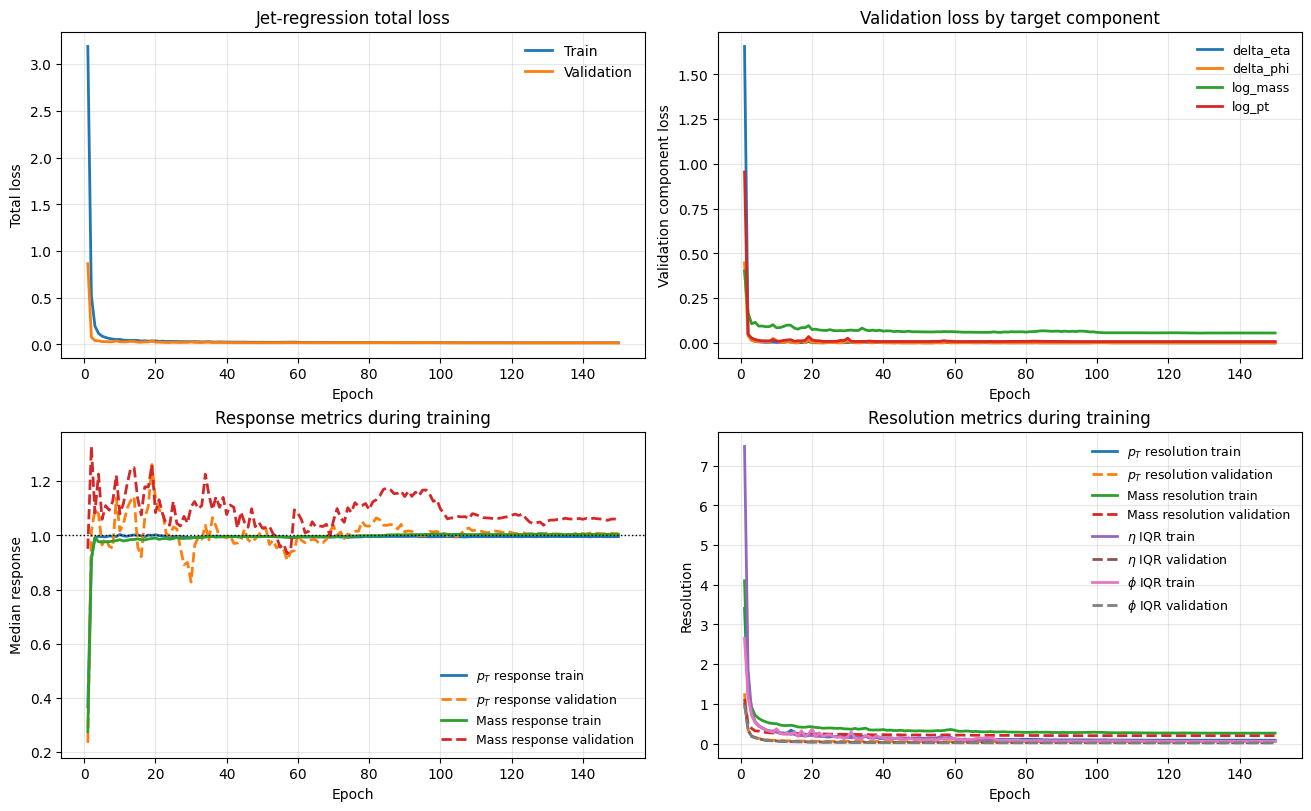

In [5]:
epochs = np.arange(1, len(history['loss_train']) + 1)
available_regression_components = sorted({
    key.removeprefix('loss_').removesuffix('_validation')
    for key in history
    if key.startswith('loss_') and key.endswith('_validation') and key != 'loss_validation'
})

fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)

axes[0, 0].plot(epochs, history['loss_train'], label='Train', linewidth=2)
axes[0, 0].plot(epochs, history['loss_validation'], label='Validation', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Total loss')
axes[0, 0].set_title('Jet-regression total loss')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(frameon=False)

for component in available_regression_components:
    axes[0, 1].plot(epochs, history[f'loss_{component}_validation'], linewidth=2, label=component)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Validation component loss')
axes[0, 1].set_title('Validation loss by target component')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend(frameon=False, fontsize=9)

for key, label in [('pt_response', r'$p_T$ response'), ('mass_response', 'Mass response')]:
    train_key = f'{key}_train'
    val_key = f'{key}_validation'
    if train_key in history and val_key in history:
        axes[1, 0].plot(epochs, history[train_key], linewidth=2, label=f'{label} train')
        axes[1, 0].plot(epochs, history[val_key], linewidth=2, linestyle='--', label=f'{label} validation')
axes[1, 0].axhline(1.0, color='black', linestyle=':', linewidth=1)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Median response')
axes[1, 0].set_title('Response metrics during training')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(frameon=False, fontsize=9)

for key, label in [('pt_resolution', r'$p_T$ resolution'), ('mass_resolution', 'Mass resolution'), ('eta_resolution', r'$\eta$ IQR'), ('phi_resolution', r'$\phi$ IQR')]:
    train_key = f'{key}_train'
    val_key = f'{key}_validation'
    if train_key in history and val_key in history:
        axes[1, 1].plot(epochs, history[train_key], linewidth=2, label=f'{label} train')
        axes[1, 1].plot(epochs, history[val_key], linewidth=2, linestyle='--', label=f'{label} validation')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Resolution')
axes[1, 1].set_title('Resolution metrics during training')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(frameon=False, fontsize=9)

plt.show()


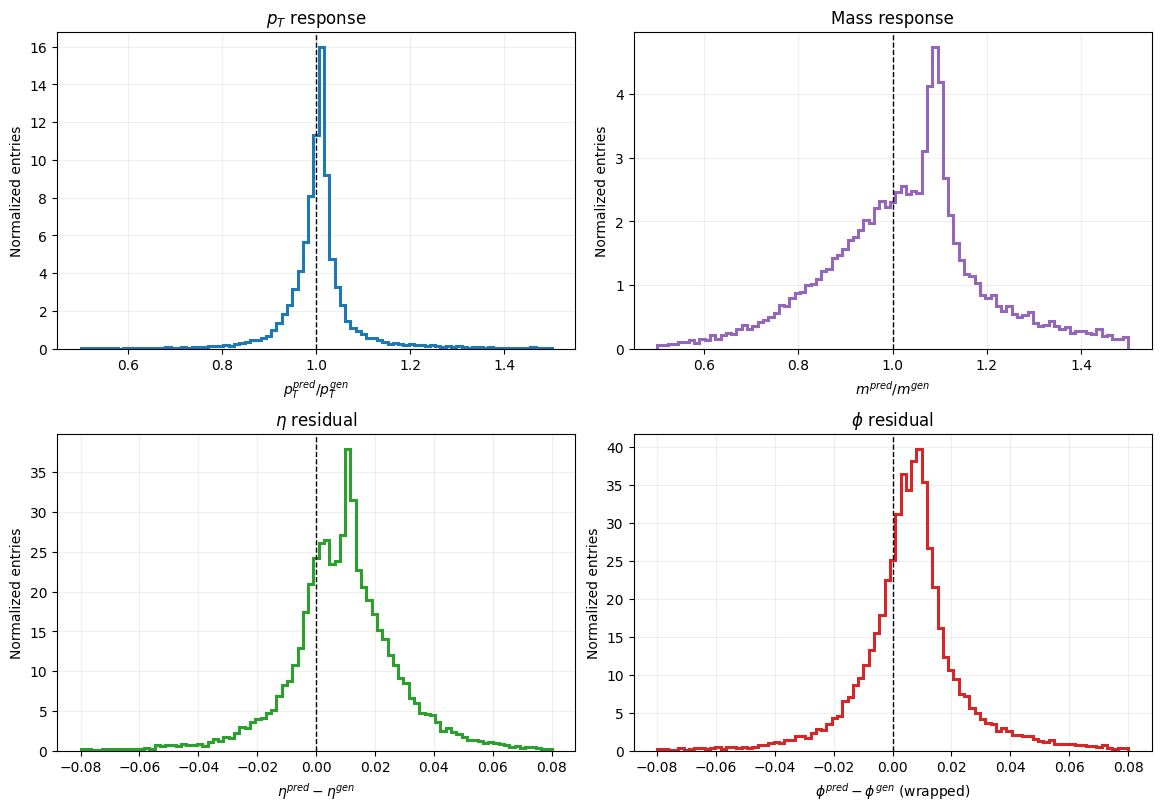

In [6]:
# Paper-style summary: component response and residual distributions
paper_bins_response = np.linspace(0.5, 1.5, 90)

def normalized_iqr(values):
    q25, q50, q75 = np.quantile(values, [0.25, 0.50, 0.75])
    return (q75 - q25) / q50 if q50 != 0 else np.nan
paper_bins_residual = np.linspace(-0.08, 0.08, 90)

fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.0), constrained_layout=True)

axes[0, 0].hist(pt_response, bins=paper_bins_response, density=True, histtype='step', linewidth=2.2, color='tab:blue')
axes[0, 0].axvline(1.0, color='black', linestyle='--', linewidth=1)
axes[0, 0].set_xlabel(r'$p_T^{pred} / p_T^{gen}$')
axes[0, 0].set_ylabel('Normalized entries')
axes[0, 0].set_title(r'$p_T$ response')
axes[0, 0].grid(True, alpha=0.2)

axes[0, 1].hist(mass_response, bins=paper_bins_response, density=True, histtype='step', linewidth=2.2, color='tab:purple')
axes[0, 1].axvline(1.0, color='black', linestyle='--', linewidth=1)
axes[0, 1].set_xlabel(r'$m^{pred} / m^{gen}$')
axes[0, 1].set_ylabel('Normalized entries')
axes[0, 1].set_title('Mass response')
axes[0, 1].grid(True, alpha=0.2)

axes[1, 0].hist(eta_residual, bins=paper_bins_residual, density=True, histtype='step', linewidth=2.2, color='tab:green')
axes[1, 0].axvline(0.0, color='black', linestyle='--', linewidth=1)
axes[1, 0].set_xlabel(r'$\eta^{pred} - \eta^{gen}$')
axes[1, 0].set_ylabel('Normalized entries')
axes[1, 0].set_title(r'$\eta$ residual')
axes[1, 0].grid(True, alpha=0.2)

axes[1, 1].hist(phi_residual, bins=paper_bins_residual, density=True, histtype='step', linewidth=2.2, color='tab:red')
axes[1, 1].axvline(0.0, color='black', linestyle='--', linewidth=1)
axes[1, 1].set_xlabel(r'$\phi^{pred} - \phi^{gen}$ (wrapped)')
axes[1, 1].set_ylabel('Normalized entries')
axes[1, 1].set_title(r'$\phi$ residual')
axes[1, 1].grid(True, alpha=0.2)

plt.show()


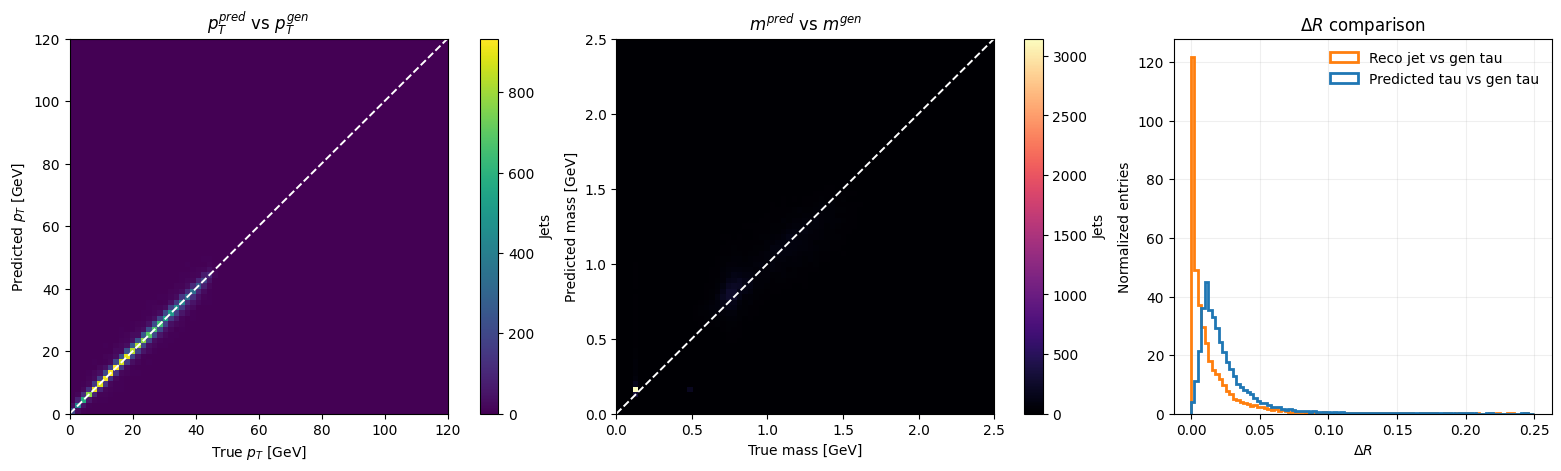

In [7]:
# Paper-style summary: prediction-vs-truth and DeltaR comparison
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6), constrained_layout=True)

h0 = axes[0].hist2d(true_pt, pred_pt, bins=[np.linspace(0, 120, 70), np.linspace(0, 120, 70)], cmap='viridis')
axes[0].plot([0, 120], [0, 120], color='white', linestyle='--', linewidth=1.4)
axes[0].set_xlabel(r'True $p_T$ [GeV]')
axes[0].set_ylabel(r'Predicted $p_T$ [GeV]')
axes[0].set_title(r'$p_T^{pred}$ vs $p_T^{gen}$')
fig.colorbar(h0[3], ax=axes[0], label='Jets')

h1 = axes[1].hist2d(true_mass, pred_mass, bins=[np.linspace(0, 2.5, 70), np.linspace(0, 2.5, 70)], cmap='magma')
axes[1].plot([0, 2.5], [0, 2.5], color='white', linestyle='--', linewidth=1.4)
axes[1].set_xlabel('True mass [GeV]')
axes[1].set_ylabel('Predicted mass [GeV]')
axes[1].set_title(r'$m^{pred}$ vs $m^{gen}$')
fig.colorbar(h1[3], ax=axes[1], label='Jets')

if source_test_path.exists():
    source_data = ak.from_parquet(source_test_path)
    reco_p4 = to_p4(source_data['reco_jet_p4s'])
    delta_r_reco_gen = ak.to_numpy(reco_p4.deltaR(gen_p4))
    axes[2].hist(delta_r_reco_gen, bins=np.linspace(0, 0.25, 100), density=True, histtype='step', linewidth=2, color='tab:orange', label='Reco jet vs gen tau')
    axes[2].hist(delta_r_pred_gen, bins=np.linspace(0, 0.25, 100), density=True, histtype='step', linewidth=2, color='tab:blue', label='Predicted tau vs gen tau')
    axes[2].legend(frameon=False)
else:
    axes[2].hist(delta_r_pred_gen, bins=np.linspace(0, 0.25, 100), density=True, histtype='step', linewidth=2, color='tab:blue', label='Predicted tau vs gen tau')
    axes[2].legend(frameon=False)

axes[2].set_xlabel(r'$\Delta R$')
axes[2].set_ylabel('Normalized entries')
axes[2].set_title(r'$\Delta R$ comparison')
axes[2].grid(True, alpha=0.2)

plt.show()


$p_T$ resolution vs true $p_T$ reco counts
  [5.00, 10.00): 3244
  [10.00, 15.00): 3812
  [15.00, 20.00): 3919
  [20.00, 25.00): 3851
  [25.00, 30.00): 3453
  [30.00, 35.00): 2792
  [35.00, 40.00): 2120
  [40.00, 45.00): 1177
  [45.00, 50.00): 40

$p_T$ resolution vs true $p_T$ model counts
  [5.00, 10.00): 3244
  [10.00, 15.00): 3812
  [15.00, 20.00): 3919
  [20.00, 25.00): 3851
  [25.00, 30.00): 3453
  [30.00, 35.00): 2792
  [35.00, 40.00): 2120
  [40.00, 45.00): 1177
  [45.00, 50.00): 40

$p_T$ response vs true $p_T$ reco counts
  [5.00, 10.00): 3244
  [10.00, 15.00): 3812
  [15.00, 20.00): 3919
  [20.00, 25.00): 3851
  [25.00, 30.00): 3453
  [30.00, 35.00): 2792
  [35.00, 40.00): 2120
  [40.00, 45.00): 1177
  [45.00, 50.00): 40

$p_T$ response vs true $p_T$ model counts
  [5.00, 10.00): 3244
  [10.00, 15.00): 3812
  [15.00, 20.00): 3919
  [20.00, 25.00): 3851
  [25.00, 30.00): 3453
  [30.00, 35.00): 2792
  [35.00, 40.00): 2120
  [40.00, 45.00): 1177
  [45.00, 50.00): 40

Mass resol

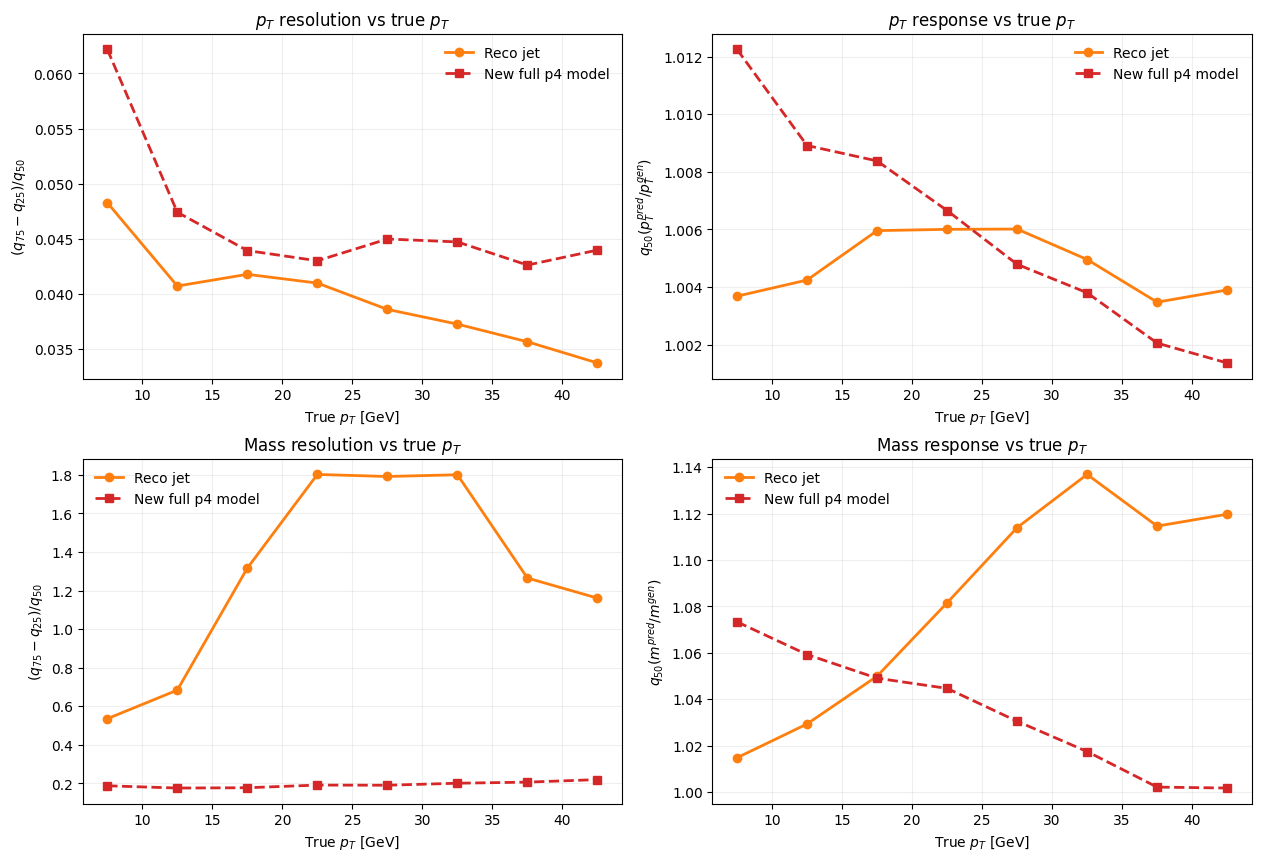

$\eta$ bias vs true $\eta$ reco counts
  [-2.05, -1.07): 3108
  [-1.07, -0.66): 3107
  [-0.66, -0.32): 3107
  [-0.32, -0.00): 3107
  [-0.00, 0.31): 3108
  [0.31, 0.64): 3107
  [0.64, 1.06): 3107
  [1.06, 2.05): 3107

$\eta$ bias vs true $\eta$ model counts
  [-2.05, -1.07): 3108
  [-1.07, -0.66): 3107
  [-0.66, -0.32): 3107
  [-0.32, -0.00): 3107
  [-0.00, 0.31): 3108
  [0.31, 0.64): 3107
  [0.64, 1.06): 3107
  [1.06, 2.05): 3107

$\eta$ resolution vs true $\eta$ reco counts
  [-2.05, -1.07): 3108
  [-1.07, -0.66): 3107
  [-0.66, -0.32): 3107
  [-0.32, -0.00): 3107
  [-0.00, 0.31): 3108
  [0.31, 0.64): 3107
  [0.64, 1.06): 3107
  [1.06, 2.05): 3107

$\eta$ resolution vs true $\eta$ model counts
  [-2.05, -1.07): 3108
  [-1.07, -0.66): 3107
  [-0.66, -0.32): 3107
  [-0.32, -0.00): 3107
  [-0.00, 0.31): 3108
  [0.31, 0.64): 3107
  [0.64, 1.06): 3107
  [1.06, 2.05): 3107

$\phi$ bias vs true $\eta$ reco counts
  [-2.05, -1.07): 3108
  [-1.07, -0.66): 3107
  [-0.66, -0.32): 3107
  [-0.32, 

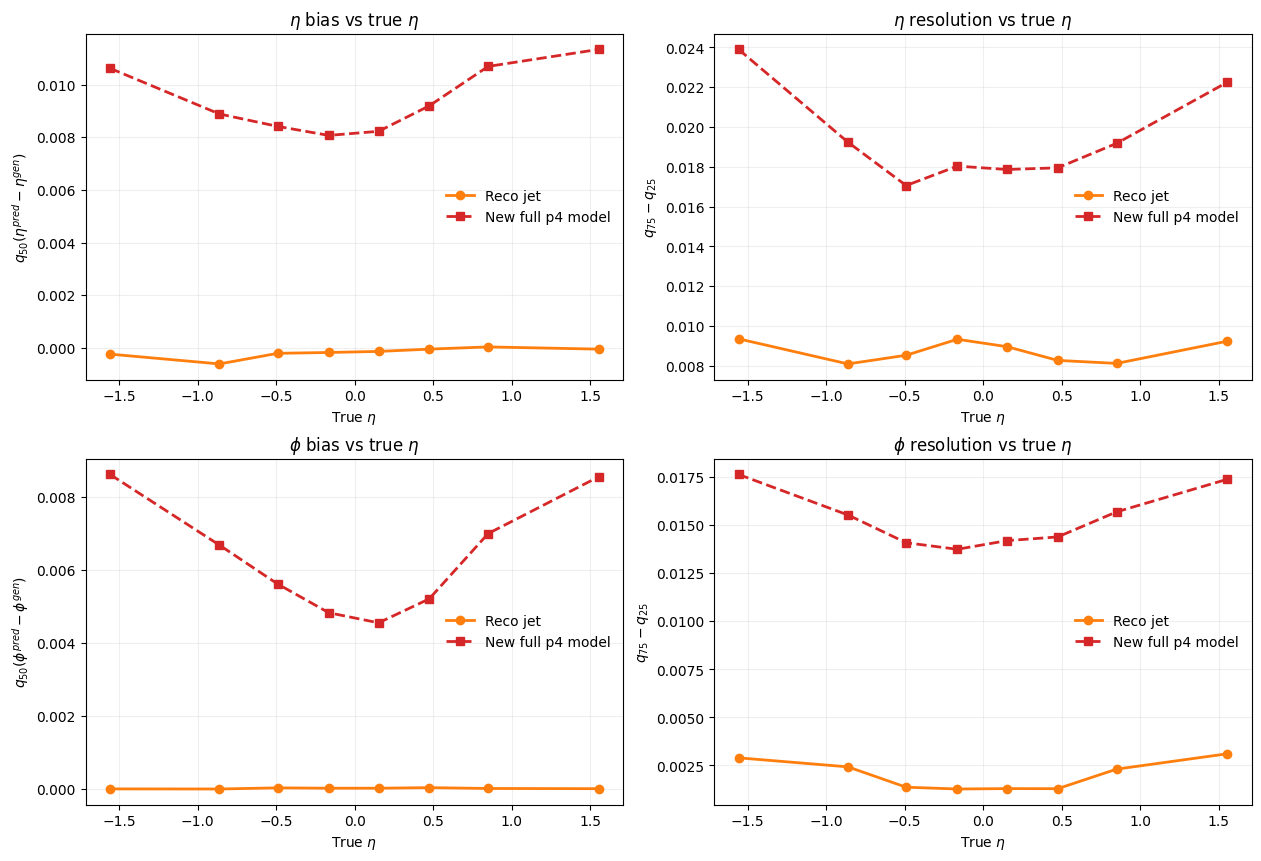

Mass response vs true mass reco counts
  [0.14, 0.14): 2798
  [0.14, 0.70): 3422
  [0.70, 0.77): 3110
  [0.77, 0.87): 3109
  [0.87, 1.02): 3110
  [1.02, 1.16): 3110
  [1.16, 1.30): 3110
  [1.30, 1.55): 3109

Mass response vs true mass model counts
  [0.14, 0.14): 2798
  [0.14, 0.70): 3422
  [0.70, 0.77): 3110
  [0.77, 0.87): 3109
  [0.87, 1.02): 3110
  [1.02, 1.16): 3110
  [1.16, 1.30): 3110
  [1.30, 1.55): 3109

Mass resolution vs true mass reco counts
  [0.14, 0.14): 2798
  [0.14, 0.70): 3422
  [0.70, 0.77): 3110
  [0.77, 0.87): 3109
  [0.87, 1.02): 3110
  [1.02, 1.16): 3110
  [1.16, 1.30): 3110
  [1.30, 1.55): 3109

Mass resolution vs true mass model counts
  [0.14, 0.14): 2798
  [0.14, 0.70): 3422
  [0.70, 0.77): 3110
  [0.77, 0.87): 3109
  [0.87, 1.02): 3110
  [1.02, 1.16): 3110
  [1.16, 1.30): 3110
  [1.30, 1.55): 3109



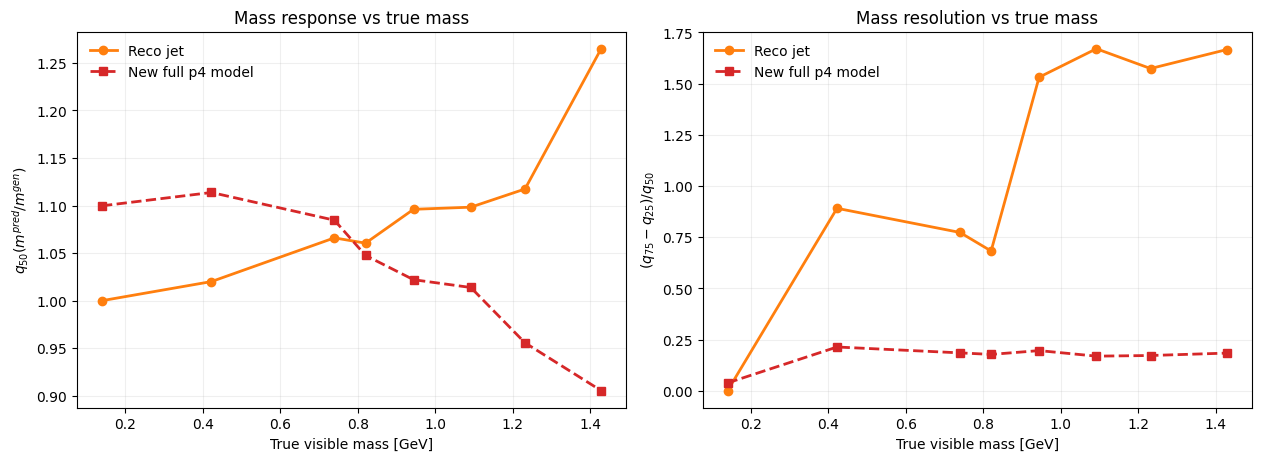

In [8]:
# Validation summary plots: use component-appropriate metrics and truth axes
if source_available:
    reco_gen_pt = ak.to_numpy(source_gen_p4.pt)
    reco_pt = ak.to_numpy(reco_p4.pt)
    reco_eta = ak.to_numpy(reco_p4.eta)
    reco_phi = ak.to_numpy(reco_p4.phi)
    reco_mass = ak.to_numpy(reco_p4.mass)

    gen_pt = ak.to_numpy(source_gen_p4.pt)
    gen_eta = ak.to_numpy(source_gen_p4.eta)
    gen_phi = ak.to_numpy(source_gen_p4.phi)
    gen_mass = ak.to_numpy(source_gen_p4.mass)

    reco_curves = {
        'pt_response': reco_pt / gen_pt,
        'mass_response': reco_mass / gen_mass,
        'eta_residual': reco_eta - gen_eta,
        'phi_residual': wrap_delta_phi(reco_phi - gen_phi),
    }
    model_curves = {
        'pt_response': pt_response,
        'mass_response': mass_response,
        'eta_residual': eta_residual,
        'phi_residual': phi_residual,
    }

    def quantile_bin_edges(values, n_bins, q_low=0.01, q_high=0.99):
        values = np.asarray(values)
        values = values[np.isfinite(values)]
        if values.size == 0:
            return np.array([])
        lo, hi = np.quantile(values, [q_low, q_high])
        if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
            return np.array([])
        edges = np.quantile(values[(values >= lo) & (values <= hi)], np.linspace(0.0, 1.0, n_bins + 1))
        edges = np.unique(edges)
        return edges if edges.size >= 2 else np.array([])

    def q50(values):
        values = np.asarray(values)
        values = values[np.isfinite(values)]
        return np.quantile(values, 0.50) if values.size else np.nan

    def iqr(values):
        values = np.asarray(values)
        values = values[np.isfinite(values)]
        if values.size == 0:
            return np.nan
        q25, q75 = np.quantile(values, [0.25, 0.75])
        return q75 - q25

    def iqr_over_q50(values):
        values = np.asarray(values)
        values = values[np.isfinite(values)]
        if values.size == 0:
            return np.nan
        q25, q50_val, q75 = np.quantile(values, [0.25, 0.50, 0.75])
        return (q75 - q25) / q50_val if q50_val != 0 else np.nan

    def plot_binned_pair(ax, x_reco, y_reco, x_model, y_model, bins, stat_fn, xlabel, ylabel, title):
        centers = 0.5 * (bins[:-1] + bins[1:])
        _, reco_curve, reco_counts = compute_binned_stats(x_reco, bins, y_reco, stat_fn)
        _, model_curve, model_counts = compute_binned_stats(x_model, bins, y_model, stat_fn)
        print_bin_counts(f'{title} reco counts', bins, reco_counts)
        print_bin_counts(f'{title} model counts', bins, model_counts)
        ax.plot(centers, reco_curve, marker='o', linewidth=2, color='tab:orange', label='Reco jet')
        ax.plot(centers, model_curve, marker='s', linewidth=2, color='tab:red', linestyle='--', label='New full p4 model')
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.grid(True, alpha=0.2)
        ax.legend(frameon=False)

    eta_bins = quantile_bin_edges(gen_eta, n_bins=8, q_low=0.02, q_high=0.98)
    mass_bins = quantile_bin_edges(gen_mass, n_bins=8, q_low=0.02, q_high=0.98)

    fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.5), constrained_layout=True)
    plot_binned_pair(
        axes[0, 0], reco_gen_pt, reco_curves['pt_response'], gen_pt, model_curves['pt_response'], pt_bins, iqr_over_q50,
        r'True $p_T$ [GeV]', r'$(q_{75} - q_{25}) / q_{50}$', r'$p_T$ resolution vs true $p_T$'
    )
    plot_binned_pair(
        axes[0, 1], reco_gen_pt, reco_curves['pt_response'], gen_pt, model_curves['pt_response'], pt_bins, q50,
        r'True $p_T$ [GeV]', r'$q_{50}(p_T^{pred}/p_T^{gen})$', r'$p_T$ response vs true $p_T$'
    )
    plot_binned_pair(
        axes[1, 0], reco_gen_pt, reco_curves['mass_response'], gen_pt, model_curves['mass_response'], pt_bins, iqr_over_q50,
        r'True $p_T$ [GeV]', r'$(q_{75} - q_{25}) / q_{50}$', r'Mass resolution vs true $p_T$'
    )
    plot_binned_pair(
        axes[1, 1], reco_gen_pt, reco_curves['mass_response'], gen_pt, model_curves['mass_response'], pt_bins, q50,
        r'True $p_T$ [GeV]', r'$q_{50}(m^{pred}/m^{gen})$', r'Mass response vs true $p_T$'
    )
    plt.show()

    if eta_bins.size >= 2:
        fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.5), constrained_layout=True)
        plot_binned_pair(
            axes[0, 0], gen_eta, reco_curves['eta_residual'], gen_eta, model_curves['eta_residual'], eta_bins, q50,
            r'True $\eta$', r'$q_{50}(\eta^{pred} - \eta^{gen})$', r'$\eta$ bias vs true $\eta$'
        )
        plot_binned_pair(
            axes[0, 1], gen_eta, reco_curves['eta_residual'], gen_eta, model_curves['eta_residual'], eta_bins, iqr,
            r'True $\eta$', r'$q_{75} - q_{25}$', r'$\eta$ resolution vs true $\eta$'
        )
        plot_binned_pair(
            axes[1, 0], gen_eta, reco_curves['phi_residual'], gen_eta, model_curves['phi_residual'], eta_bins, q50,
            r'True $\eta$', r'$q_{50}(\phi^{pred} - \phi^{gen})$', r'$\phi$ bias vs true $\eta$'
        )
        plot_binned_pair(
            axes[1, 1], gen_eta, reco_curves['phi_residual'], gen_eta, model_curves['phi_residual'], eta_bins, iqr,
            r'True $\eta$', r'$q_{75} - q_{25}$', r'$\phi$ resolution vs true $\eta$'
        )
        plt.show()
    else:
        print('Eta binning could not be constructed. Angular summary plots skipped.')

    if mass_bins.size >= 2:
        fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5), constrained_layout=True)
        plot_binned_pair(
            axes[0], gen_mass, reco_curves['mass_response'], gen_mass, model_curves['mass_response'], mass_bins, q50,
            r'True visible mass [GeV]', r'$q_{50}(m^{pred}/m^{gen})$', r'Mass response vs true mass'
        )
        plot_binned_pair(
            axes[1], gen_mass, reco_curves['mass_response'], gen_mass, model_curves['mass_response'], mass_bins, iqr_over_q50,
            r'True visible mass [GeV]', r'$(q_{75} - q_{25}) / q_{50}$', r'Mass resolution vs true mass'
        )
        plt.show()
    else:
        print('Mass binning could not be constructed. Mass-vs-mass summary plots skipped.')
else:
    print('Source CLD test parquet not available in this workspace. Validation summary plots skipped.')



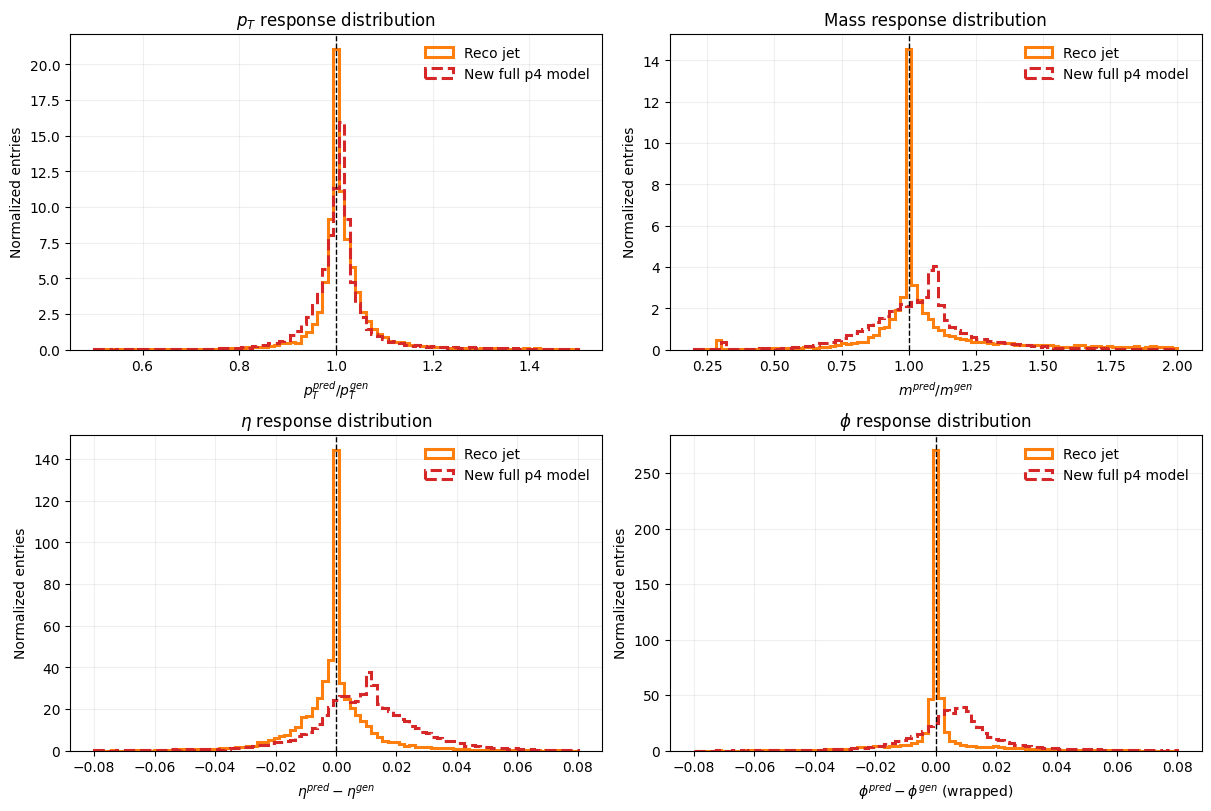

In [9]:
# Component response / residual distributions: reco jet vs new full p4 model
if source_available:
    reco_gen_pt = ak.to_numpy(source_gen_p4.pt)
    reco_pt = ak.to_numpy(reco_p4.pt)
    reco_eta = ak.to_numpy(reco_p4.eta)
    reco_phi = ak.to_numpy(reco_p4.phi)
    reco_mass = ak.to_numpy(reco_p4.mass)
    gen_eta = ak.to_numpy(source_gen_p4.eta)
    gen_phi = ak.to_numpy(source_gen_p4.phi)
    gen_mass = ak.to_numpy(source_gen_p4.mass)

    reco_curves = {
        'pt_response': reco_pt / reco_gen_pt,
        'mass_response': reco_mass / gen_mass,
        'eta_response': reco_eta - gen_eta,
        'phi_response': wrap_delta_phi(reco_phi - gen_phi),
    }

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

    axes[0, 0].hist(reco_curves['pt_response'], bins=np.linspace(0.5, 1.5, 90), density=True, histtype='step', linewidth=2.2, color='tab:orange', label='Reco jet')
    axes[0, 0].hist(pt_response, bins=np.linspace(0.5, 1.5, 90), density=True, histtype='step', linewidth=2.2, color='tab:red', linestyle='--', label='New full p4 model')
    axes[0, 0].axvline(1.0, color='black', linestyle='--', linewidth=1)
    axes[0, 0].set_xlabel(r'$p_T^{pred} / p_T^{gen}$')
    axes[0, 0].set_ylabel('Normalized entries')
    axes[0, 0].set_title(r'$p_T$ response distribution')
    axes[0, 0].legend(frameon=False)

    axes[0, 1].hist(reco_curves['mass_response'], bins=np.linspace(0.2, 2.0, 90), density=True, histtype='step', linewidth=2.2, color='tab:orange', label='Reco jet')
    axes[0, 1].hist(mass_response, bins=np.linspace(0.2, 2.0, 90), density=True, histtype='step', linewidth=2.2, color='tab:red', linestyle='--', label='New full p4 model')
    axes[0, 1].axvline(1.0, color='black', linestyle='--', linewidth=1)
    axes[0, 1].set_xlabel(r'$m^{pred} / m^{gen}$')
    axes[0, 1].set_ylabel('Normalized entries')
    axes[0, 1].set_title('Mass response distribution')
    axes[0, 1].legend(frameon=False)

    axes[1, 0].hist(reco_curves['eta_response'], bins=np.linspace(-0.08, 0.08, 90), density=True, histtype='step', linewidth=2.2, color='tab:orange', label='Reco jet')
    axes[1, 0].hist(eta_residual, bins=np.linspace(-0.08, 0.08, 90), density=True, histtype='step', linewidth=2.2, color='tab:red', linestyle='--', label='New full p4 model')
    axes[1, 0].axvline(0.0, color='black', linestyle='--', linewidth=1)
    axes[1, 0].set_xlabel(r'$\eta^{pred} - \eta^{gen}$')
    axes[1, 0].set_ylabel('Normalized entries')
    axes[1, 0].set_title(r'$\eta$ response distribution')
    axes[1, 0].legend(frameon=False)

    axes[1, 1].hist(reco_curves['phi_response'], bins=np.linspace(-0.08, 0.08, 90), density=True, histtype='step', linewidth=2.2, color='tab:orange', label='Reco jet')
    axes[1, 1].hist(phi_residual, bins=np.linspace(-0.08, 0.08, 90), density=True, histtype='step', linewidth=2.2, color='tab:red', linestyle='--', label='New full p4 model')
    axes[1, 1].axvline(0.0, color='black', linestyle='--', linewidth=1)
    axes[1, 1].set_xlabel(r'$\phi^{pred} - \phi^{gen}$ (wrapped)')
    axes[1, 1].set_ylabel('Normalized entries')
    axes[1, 1].set_title(r'$\phi$ response distribution')
    axes[1, 1].legend(frameon=False)

    for ax in axes.flat:
        ax.grid(True, alpha=0.2)

    plt.show()
else:
    print('Source CLD test parquet not available in this workspace. Component response distributions skipped.')
